# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Ritika

**Roll Number:** 023-24-0262

**GitHub Repository:** https://github.com/Ritika-Lund/Machine-learning-Lab.git

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")  


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The telecommunications company wants to identify customers who are likely to leave so it can take action before they churn. The goal is to understand which customer and service characteristics may be associated with churn. The target variable is Churn, which indicates whether a customer has left the company (Yes or No).

**Answer 2:**
These are the features i think will be useful and useless,confirmation can be only given after performing EDA



Useful features 
1)Contract 
2)Tenure
3)Monthly charges
4)PaymentMethod
5)InternetService

Useless Features
1)customerID
2)Gender

**Answer 3:**
1)Are customers with month-to-month contracts more likely to churn(leave) than customers with one-year or two-year contracts?
2)How much customer tenure is connected to customers who churn or customers who stay?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [3]:
# Task 4 — dataset shape, column names, data types
print("No of rows and columns :")
print(df.shape)
# there are total 21 columns from these 19 are features 1 is identifier 1 is target variable.

print("\nColumn data types:")
print(df.dtypes)
#  numerical 
    # tenure
    # MonthlyCharges
# categorical
    # gender
    # Partner
    # Dependents
    # PhoneService
    # MultipleLines
    # InternetService
    # OnlineSecurity
    # OnlineBackup
    # DeviceProtection
    # TechSupport
    # StreamingTV
    # StreamingMovies
    # Contract
    # PaperlessBilling
    # PaymentMethod
# seniorCitizen is in binary category


No of rows and columns :
(7043, 21)

Column data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
# Task 5 — identify identifier columns / wrong data types
# customerId is identifier,it is not a meaningful predictive feature
df["TotalCharges"].dtype
# TotalCharges should be float but instead it is string which is wrong data type

<StringDtype(na_value=nan)>

In [5]:
# Task 6 — unique values in 3 categorical columns
print(df['Contract'].unique())
print(df['InternetService'].unique())
print(df['PaymentMethod'].unique())

<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
<ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


**Observations (Part 2):**
The dataset contains 7,043 customers and 21 columns. customerID is an identifier and Churn is the target variable. tenure and MonthlyCharges are numerical features, while most of the remaining features are categorical. SeniorCitizen is stored as an integer but represents a binary category. TotalCharges is numerical in meaning but is stored as object, making it a suspicious column that requires further investigation. The three categorical columns examined using unique() did not show obvious inconsistent categories.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [6]:
# Task 7 — missing values: count and percentage per column
missing_values_count=df.isnull().sum()
print(missing_values_count)
print("\npercentage of missing values:")
missing_values_percentage=(df.isnull().mean() * 100)
print(missing_values_percentage)
df["TotalCharges"].str.strip().eq('').sum()
blank_totalcharges = df['TotalCharges'].str.strip().eq('').sum()

blank_percentage = (blank_totalcharges / len(df)) * 100

print("Blank TotalCharges:", blank_totalcharges)
print("Percentage:", blank_percentage)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

percentage of missing values:
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn         

In [7]:
# Task 8 — duplicate rows vs duplicate IDs
duplicate_rows=df.duplicated().sum()
print("No of duplicate rows in this dataset :",duplicate_rows)
duplicate_customerIds=df['customerID'].duplicated().sum()
print("No of duplicate customerIDs in this dataset :",duplicate_customerIds)


No of duplicate rows in this dataset : 0
No of duplicate customerIDs in this dataset : 0


In [8]:
# Task 9 — investigate a suspicious / invalid value
print(df['TotalCharges'].tail())
df[df['TotalCharges'].str.strip() == '']

7038    1990.5
7039    7362.9
7040    346.45
7041     306.6
7042    6844.5
Name: TotalCharges, dtype: str


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


**Answer 7 (which missing-value problems need action, and why):**
 Task 7 related observation
 The standard isnull() check reports no missing values in the dataset. However, further investigation of TotalCharges revealed 11 blank values
 These blanks are effectively missing information even though Pandas does not identify them as NaN
 This issue requires action because TotalCharges represents a numerical quantity and the blank values will interfere with converting the column to a numeric data type.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
this dataset contains 0 duplicated rows and 0 duplicate customerIDs.both check represent different issues because duplicate rows mean the entire record has been repeated ,while dupliacte customer id means same customer is appearning in multiple records.

**Answer 9 (suspicious value found and how):**
TotalCharges was identified as a suspicious column because it represents a numerical amount but has an object data type. Further inspection showed 11 records containing blank strings. These values were detected by stripping whitespace and checking for empty strings. The issue needs to be addressed before the column can be used as a numerical feature.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**


| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| 11 blank values in TotalCharges | Convert blanks to missing values and fill them with 0 | pd.to_numeric() and fillna(0) | The affected customers have zero tenure, so a total charge of 0 is a reasonable assumption. |
| TotalCharges has the wrong data type | Convert TotalCharges to numeric | pd.to_numeric() | TotalCharges represents a amount, so it should be stored as a numerical value for analysis and future ML use. |
| Duplicate rows | No action required | df.duplicated().sum() | No duplicate rows were found in the original dataset. |
| Duplicate customer IDs | No action required | df['customerID'].duplicated().sum() | No duplicate customer IDs were found, so each customer appears only once. |
| customerID is an identifier | Remove it from the ML-ready dataset | drop(columns=['customerID']) | customerID only identifies customers and does not represent a meaningful characteristic for predicting churn. |

In [9]:
# Task 11 — apply your cleaning decisions here
clean_df = df.copy()
clean_df['TotalCharges'] = pd.to_numeric(
    clean_df['TotalCharges'],
    errors='coerce'
)
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0)
clean_df = clean_df.drop(columns=['customerID'])

In [10]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Missing values:")
print(clean_df.isnull().sum())

print("\nData types:")
print(clean_df.dtypes)

print("\nDuplicate customer records before removing ID:")
print(df.duplicated().sum())

print("\nDuplicate customer IDs:")
print(df['customerID'].duplicated().sum())

print("\nShape:")
print(clean_df.shape)

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges  

### Task 11 — Verification

The cleaning steps resolved the identified data-quality issues. The blank TotalCharges values were converted to missing values and then filled with 0, so there are now no missing values in the cleaned dataset. TotalCharges is now stored as a numerical data type. The original dataset had no duplicate rows or duplicate customer IDs. The customerID column was removed from clean_df because it is an identifier rather than a predictive feature.

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

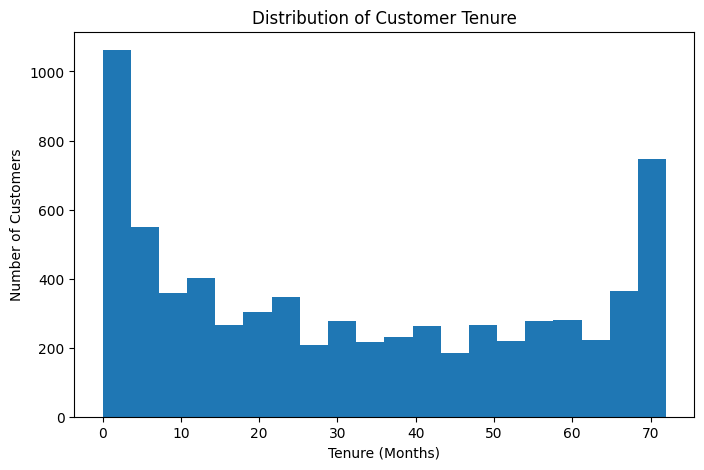

In [11]:
# Task 12 — numerical feature 1: distribution plot
plt.figure(figsize=(8, 5))

clean_df['tenure'].plot(kind='hist', bins=20)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

**Observation:** The distribution of customer tenure is uneven, with a particularly large number of customers having very short tenure and another noticeable concentration around 70–72 months. Customers with medium tenure are less common, so the distribution does not appear uniform across the tenure range

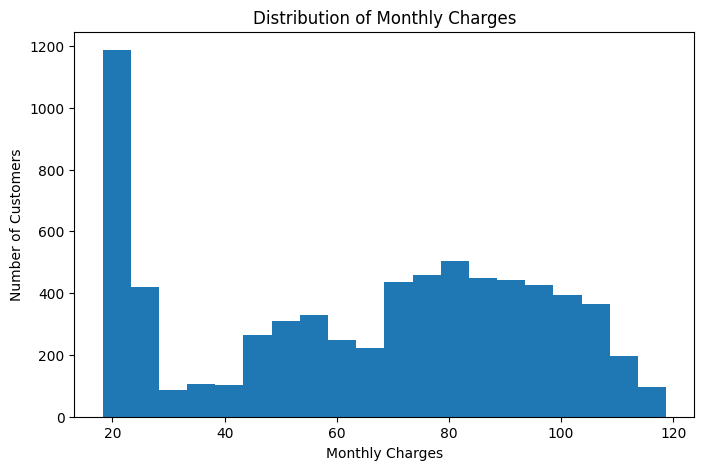

In [12]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(8, 5))

clean_df['MonthlyCharges'].plot(kind='hist', bins=20)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

**Observation:** The distribution of monthly charges is uneven,with a very large concentration of customers at the lower charge range and another broader concentration between approximately 45 and 110.The distribution appears somewhat bimodal(two peaks), with a noticeable gap around the 30–40 range.

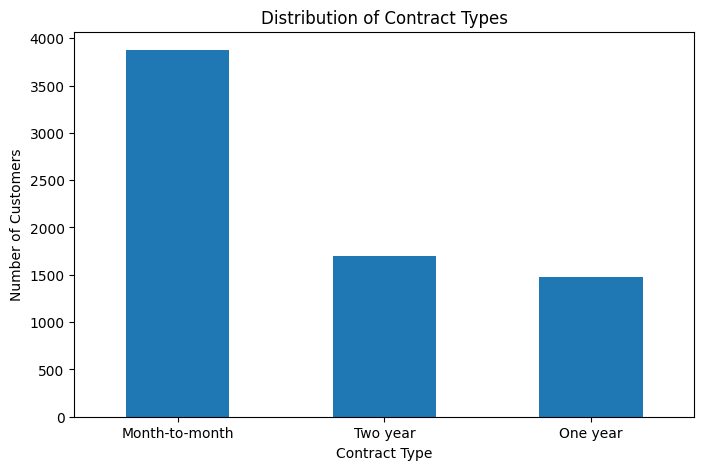

In [13]:
# Task 12 — categorical feature 1: distribution plot
plt.figure(figsize=(8, 5))

clean_df['Contract'].value_counts().plot(kind='bar')

plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

**Observation:** The majority of customers have month-to-month contracts, with roughly 3,900 customers in this category. Two-year and one-year contracts are less common, with one-year contracts being the least represented group.

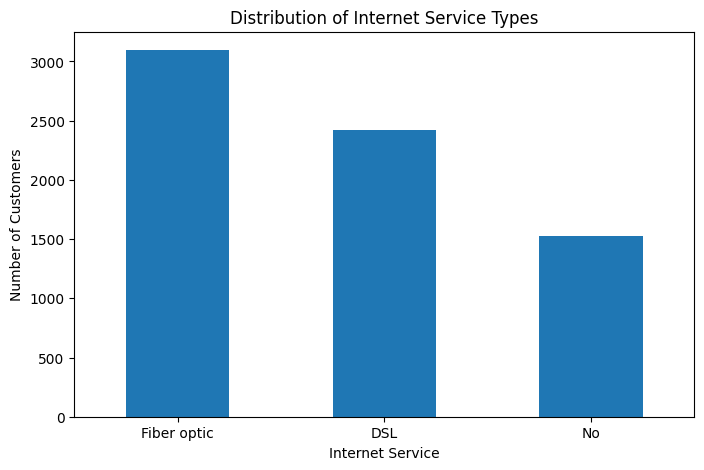

In [14]:
# Task 12 — categorical feature 2: distribution plot
plt.figure(figsize=(8, 5))

clean_df['InternetService'].value_counts().plot(kind='bar')

plt.title('Distribution of Internet Service Types')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

**Observation:** Fiber optic is the most common internet service type in the dataset, followed by DSL. Customers with no internet service form the smallest group, with noticeably fewer customers than the other two categories.

**Answer 13 (outliers / skew and possible explanation):**
The numerical features show different distribution patterns. tenure has a non-uniform distribution, with many customers having low tenure and another concentration of customers with long tenure. MonthlyCharges is more spread out and shows some higher-charge observations. These patterns are reasonable for this dataset because customers can have very different lengths of service and can subscribe to different combinations of services, resulting in different monthly charges.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [15]:
# Task 14 — churn counts and percentages
churn_count=clean_df['Churn'].value_counts()
churn_percentages=clean_df['Churn'].value_counts(normalize=True)*100
print("Number of customers:")
print(churn_count)

print("\nPercentage of customers:")
print(churn_percentages.round(2))


Number of customers:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage of customers:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):** 5174 customers(73.46) are the customers who did not churn  and 1869 customers(26.54) are the customers who churned.Therefore we can clearly see that the target variable (Churn)is imbalanced because the teo classes are not equally represented.

**Answer 15 (why imbalance might matter later):**
Class imbalance matters because a classification model may perform well on the majority class while performing poorly on the minority class. In this dataset, accuracy alone may not fully represent how well the model identifies customers who churn.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


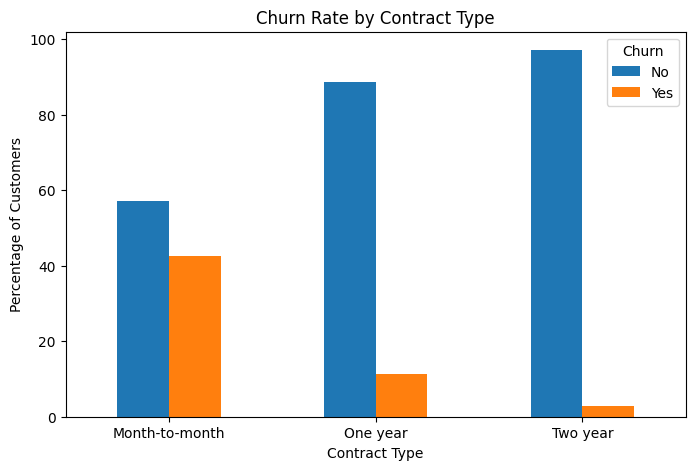

In [16]:
# Task 16 — categorical feature 1 vs Churn
contract_churn=pd.crosstab(clean_df['Contract'],clean_df['Churn'],normalize='index') * 100
print(contract_churn.round(2))
contract_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()


**Observation:** Churn rates differ substantially across contract types. Month-to-month customers have the highest churn rate, while customers with two-year contracts have the lowest churn rate.

**Evidence:** The churn rate is 42.71% for month-to-month customers, 11.27% for one-year customers, and only 2.83% for two-year customers.

**Possible Explanation:** Customers with longer-term contracts may be more committed to the service and therefore less likely to leave, while month-to-month customers have more flexibility to switch or cancel their service.

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


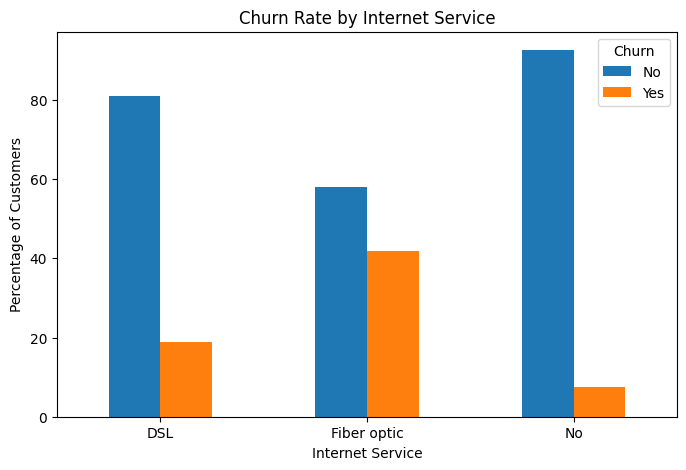

In [17]:
# Task 16 — categorical feature 2 vs Churn
internet_churn = pd.crosstab(
    clean_df['InternetService'],
    clean_df['Churn'],
    normalize='index'
) * 100

print(internet_churn.round(2))
internet_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**Observation:** Churn rates differ across internet service types, with fiber-optic customers having the highest churn rate and customers without internet service having the lowest churn rate.

**Evidence:** The churn rate is 41.89% for fiber-optic customers, 18.96% for DSL customers, and 7.40% for customers without internet service.

**Possible Explanation:** The higher churn among fiber-optic customers may be related to differences in service cost, customer expectations, or other characteristics of this customer group. Further analysis would be needed to determine the underlying reason.

        mean  median  min  max
Churn                         
No     37.57    38.0    0   72
Yes    17.98    10.0    1   72


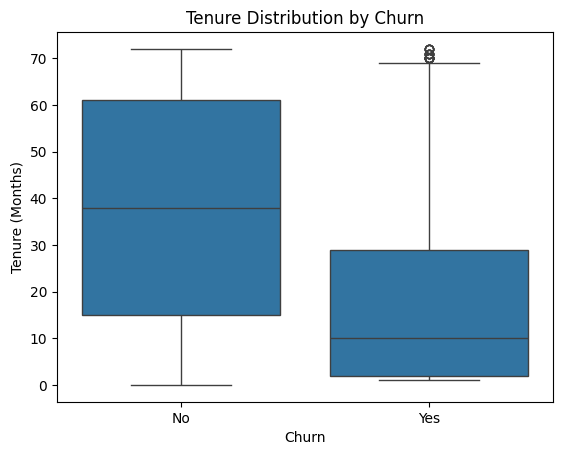

In [24]:
# Task 17 — numerical feature 1 vs Churn
print(
    clean_df.groupby('Churn')['tenure']
    .agg(['mean', 'median', 'min', 'max'])
    .round(2)
)
sns.boxplot(
    data=clean_df,
    x='Churn',
    y='tenure'
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

**Observation:** Customers who churn generally have much shorter tenure than customers who do not churn.

**Evidence:** The average tenure is 17.98 months for customers who churned compared with 37.57 months for customers who did not churn. The median tenure is also much lower for churned customers (10 months) than for non-churned customers (38 months)

**Possible Explanation:** Customers who have recently joined the company may be less committed to the service or may leave if their expectations are not met. Longer-tenure customers may have greater loyalty or satisfaction with the service.

        mean  median    min     max
Churn                              
No     61.27   64.43  18.25  118.75
Yes    74.44   79.65  18.85  118.35


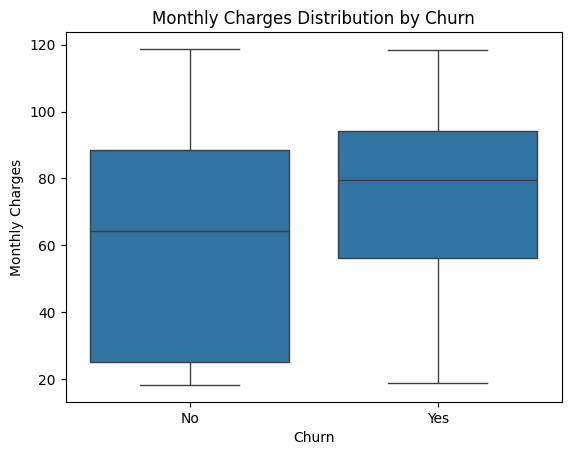

In [25]:
# Task 17 — numerical feature 2 vs Churn
print(
    clean_df.groupby('Churn')['MonthlyCharges']
    .agg(['mean', 'median', 'min', 'max'])
    .round(2)
)
sns.boxplot(
    data=clean_df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

**Observation:** Customers who churn generally have higher monthly charges than customers who do not churn.

**Evidence:** The average monthly charge is 74.44 for customers who churned compared with 61.27 for customers who did not churn. The median monthly charge is also higher for churned customers (79.65) than for non-churned customers (64.43). 

**Possible Explanation:** Customers paying higher monthly charges may have different or more expensive service combinations, which could be associated with a higher likelihood of leaving. However, higher charges alone do not prove that they cause churn.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.25          0.83
MonthlyCharges    0.25            1.00          0.65
TotalCharges      0.83            0.65          1.00


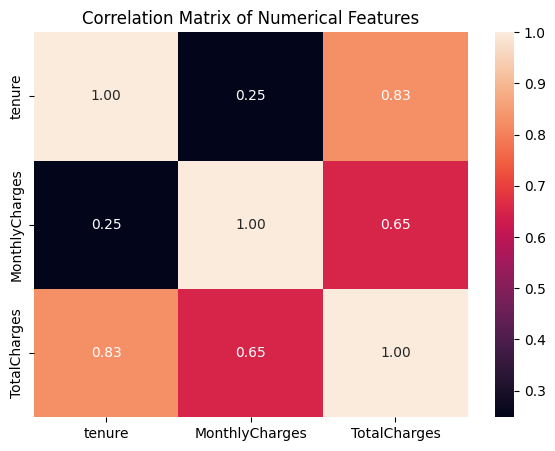

In [20]:
# Task 18 — correlation matrix and heatmap
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

corr_matrix = clean_df[numeric_cols].corr()

print(corr_matrix.round(2))

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Answer 18 (most correlated pairs):**
The strongest positive correlation is between tenure and TotalCharges (0.83), indicating that customers with longer tenure generally have higher total charges. MonthlyCharges and TotalCharges also show a moderately strong positive correlation (0.65), while tenure and MonthlyCharges have a weaker positive correlation (0.25). These relationships suggest that both the length of time a customer stays and their monthly charges are related to the total amount charged.

**Answer 19 (correlation vs. causation; potential problems):**
Correlation does not imply causation it only shows that two variables have a tendency to vary together. In this dataset, tenure and TotalCharges have a strong positive correlation (0.83), so they may contain some overlapping information, which could create redundancy for a future model.


---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
customerID is Identifier It only identifies the customer and does not represent a meaningful customer characteristic for predicting churn.
Churn is Target, not a feature Churn is the outcome we are trying to predict, so it must not be included as an input feature.
I did not find another column that clearly represents information that would only become available after the customer had already churned. Therefore, there is no obvious post-churn leakage column in the dataset.

**Answer 21 (what would go wrong):**
If a post-churn or target-related column were included as an input feature, the model could use information that would not realistically be available when making the prediction. This could make the model appear highly accurate during evaluation while giving misleading results in a real-world situation.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| `customerID` | Identifier | Identifier | Remove | Only identifies the customer and does not provide meaningful predictive information. |
| `gender` | Categorical | Feature | Keep | Represents a customer characteristic that can potentially be used as a predictor. |
| `SeniorCitizen` | Binary categorical | Feature | Keep | Represents whether the customer is a senior citizen and may contain information related to churn. |
| `Partner` | Categorical | Feature | Keep | Indicates whether the customer has a partner and may be useful for predicting churn. |
| `Dependents` | Categorical | Feature | Keep | Indicates whether the customer has dependents and may contain predictive information. |
| `tenure` | Numerical | Feature | Keep | Represents how long the customer has stayed with the company and may be related to churn. |
| `PhoneService` | Categorical | Feature | Keep | Represents whether the customer has phone service. |
| `MultipleLines` | Categorical | Feature | Keep | Represents the customer's multiple-line service status. |
| `InternetService` | Categorical | Feature | Keep | Represents the type of internet service and may be related to churn. |
| `OnlineSecurity` | Categorical | Feature | Keep | Represents whether the customer has online security service. |
| `OnlineBackup` | Categorical | Feature | Keep | Represents whether the customer has online backup service. |
| `DeviceProtection` | Categorical | Feature | Keep | Represents whether the customer has device protection service. |
| `TechSupport` | Categorical | Feature | Keep | Represents whether the customer has technical support service. |
| `StreamingTV` | Categorical | Feature | Keep | Represents whether the customer has streaming TV service. |
| `StreamingMovies` | Categorical | Feature | Keep | Represents whether the customer has streaming movie service. |
| `Contract` | Categorical | Feature | Keep | Represents the customer's contract type and may be related to churn. |
| `PaperlessBilling` | Categorical | Feature | Keep | Represents the customer's billing preference. |
| `PaymentMethod` | Categorical | Feature | Keep | Represents how the customer pays and may contain useful predictive information. |
| `MonthlyCharges` | Numerical | Feature | Keep | Represents the customer's monthly charges and may be related to churn. |
| `TotalCharges` | Numerical | Feature | Clean, then Keep | It represents total customer charges, but the original column contained blank values and had an object data type. It was converted to numeric and blank values were handled. |
| `Churn` | Categorical | Target | Keep as target | This is the outcome we want to predict, so it should not be used as an input feature. |

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [21]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# Convert TotalCharges to numeric
clean_df['TotalCharges'] = pd.to_numeric(
    clean_df['TotalCharges'],
    errors='coerce'
)

# Fill missing TotalCharges values with 0
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0)

# Remove customerID because it is only an identifier
clean_df = clean_df.drop(columns=['customerID'])

# Check the final shape
print("Final shape:", clean_df.shape)

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


Final shape: (7043, 20)


In [22]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 2**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 3**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 4**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 5**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _(your answer here)_
2. What was the most interesting pattern you discovered?
   _(your answer here)_
3. Which feature seems most useful for predicting churn?
   _(your answer here)_
4. Which feature should probably not be used, and why?
   _(your answer here)_
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _(your answer here)_
6. What would you do next if you had another 3 hours?
   _(your answer here)_

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [23]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook